[*********************100%***********************]  1 of 1 completed


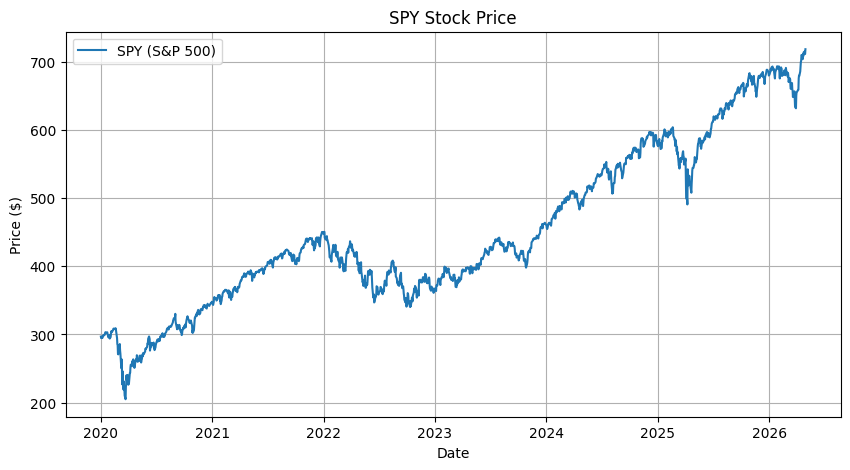

In [10]:
import yfinance as yf
import matplotlib.pyplot as plt

# multi_level_index=False 로 멀티인덱스 비활성화
spy_data = yf.download(
    'SPY',
    start='2020-01-01',
    end='2026-05-01',
    auto_adjust=True,
    multi_level_index=False   # auto_adjust=True를 써도 최신 yfinance는 멀티인덱스 컬럼으로 반환해서 spy_data['Close']도 못 찾는 상황이야.해결 — multi_level_index=False 추가
)

plt.figure(figsize=(10, 5))
plt.plot(spy_data['Close'], label='SPY (S&P 500)')
plt.title('SPY Stock Price')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()


[*********************100%***********************]  3 of 3 completed


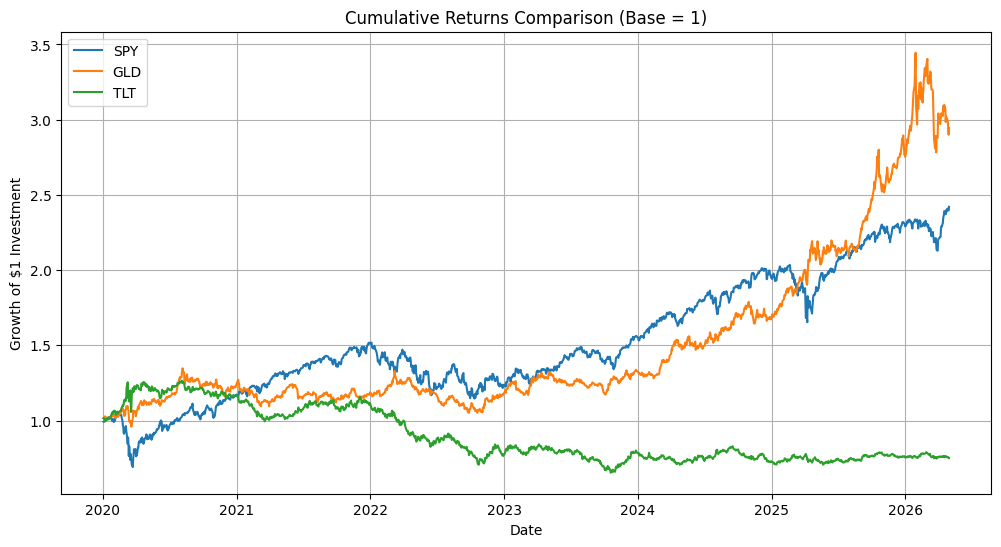

--- 2020년 이후 자산별 최대 낙폭(MDD) ---
SPY: -33.72%
GLD: -22.00%
TLT: -48.35%


In [11]:
import yfinance as yf
import matplotlib.pyplot as plt

tickers = ['SPY', 'GLD', 'TLT']

# auto_adjust=True + multi_level_index=False 두 옵션 모두 추가
data = yf.download(
    tickers,
    start='2020-01-01',
    end='2026-05-01',
    auto_adjust=True, #Close가 수정 종가로 자동 전환
    multi_level_index=False #컬럼 구조 단순화
)['Close']  # 'Adj Close' → 'Close'

cumulative_returns = (1 + data.pct_change()).cumprod()

plt.figure(figsize=(12, 6))
for ticker in tickers:
    plt.plot(cumulative_returns[ticker], label=ticker)
plt.title('Cumulative Returns Comparison (Base = 1)')
plt.xlabel('Date')
plt.ylabel('Growth of $1 Investment')
plt.legend()
plt.grid(True)
plt.show()

import numpy as np

# 1. 각 자산의 누적 최고점(Peak) 계산
rolling_max = data.cummax()

# 2. 최고점 대비 현재 얼마나 하락했는지 낙폭(Drawdown) 계산
drawdowns = (data - rolling_max) / rolling_max

# 3. 그 낙폭 중 가장 바닥인 지점(MDD) 추출
mdd = drawdowns.min()

# 4. 보기 좋게 퍼센트(%)로 출력
print("--- 2020년 이후 자산별 최대 낙폭(MDD) ---")
for ticker in tickers:
    print(f"{ticker}: {mdd[ticker]*100:.2f}%")

💥 혼합 포트폴리오 (SPY 40% / GLD 30% / TLT 30%)의 MDD
👉 -22.63%



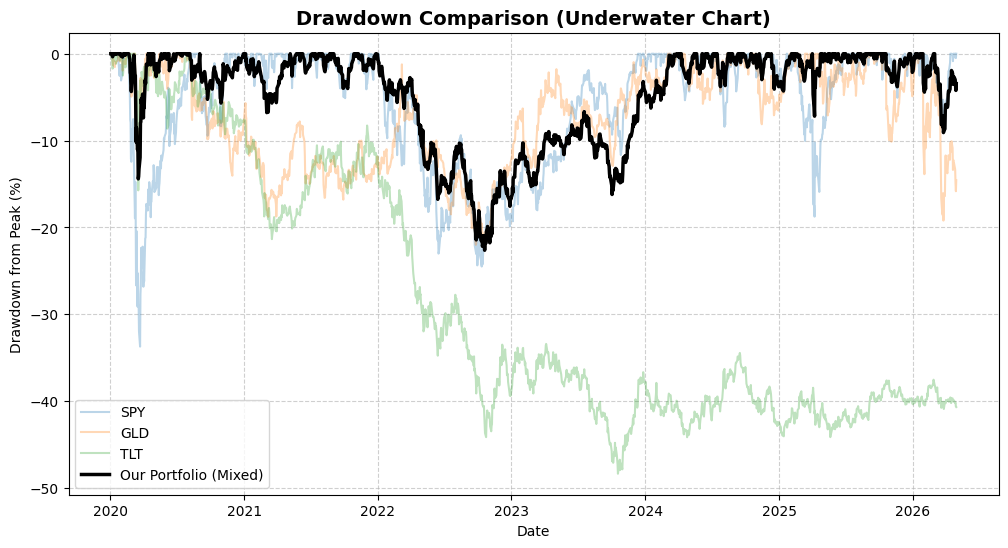

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 어제 가져온 자산 데이터의 일별 수익률 재계산
returns = data.pct_change().dropna()

# 2. 포트폴리오 비중 설정 (주식 40%, 금 30%, 채권 30%)
weights = {'SPY': 0.4, 'GLD': 0.3, 'TLT': 0.3}

# 3. 비중을 반영한 포트폴리오의 일별 수익률 합성
portfolio_return = sum(returns[ticker] * weight for ticker, weight in weights.items())

# 4. 포트폴리오의 누적 수익률 계산
portfolio_cumulative = (1 + portfolio_return).cumprod()

# 5. 포트폴리오의 MDD 계산
port_rolling_max = portfolio_cumulative.cummax()
port_drawdown = (portfolio_cumulative - port_rolling_max) / port_rolling_max
port_mdd = port_drawdown.min()

print("=" * 45)
print(f"💥 혼합 포트폴리오 (SPY 40% / GLD 30% / TLT 30%)의 MDD")
print(f"👉 {port_mdd * 100:.2f}%")
print("=" * 45 + "\n")

# 6. 자산별 & 포트폴리오 낙폭(Drawdown) 시각화 (Underwater Chart)
plt.figure(figsize=(12, 6))
for ticker in tickers:
    # 개별 자산들의 낙폭은 흐릿하게(alpha=0.3) 그리기
    asset_cum = (1 + returns[ticker]).cumprod()
    asset_drawdown = (asset_cum - asset_cum.cummax()) / asset_cum.cummax()
    plt.plot(asset_drawdown * 100, label=ticker, alpha=0.3)

# 우리가 만든 혼합 포트폴리오 낙폭은 검은색 굵은 선으로 강조
plt.plot(port_drawdown * 100, label='Our Portfolio (Mixed)', color='black', linewidth=2.5)

plt.title('Drawdown Comparison (Underwater Chart)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Drawdown from Peak (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [13]:
import numpy as np
import pandas as pd

# 1. 연율화된 수익률 (Annualized Return) 계산 - 기하평균 기준
# (일별 수익률을 1년 영업일 252일 기준으로 환산)
annualized_return = (portfolio_cumulative.iloc[-1]) ** (252 / len(portfolio_return)) - 1

# 2. 연율화된 변동성 (Annualized Volatility) 계산
# (일별 수익률의 표준편차에 루트 252를 곱해 환산)
annualized_volatility = portfolio_return.std() * np.sqrt(252)

# 3. MDD (어제 구한 값 활용)
# port_mdd는 이미 계산되어 있으므로 그대로 사용

# 4. Historical VaR (95% 신뢰수준) 계산
# (하위 5%에 해당하는 일별 손실을 구한 뒤, 이를 연간 기준으로 보기 쉽게 변환하거나 일별 기준으로 제시)
# 여기서는 가장 직관적인 일별 95% VaR를 구합니다. (오늘 하루 95% 확률로 이 이상 손실나지 않는다)
var_95_daily = np.percentile(portfolio_return, 5)

# 5. 깔끔하게 데이터프레임으로 정리
metrics_summary = pd.DataFrame({
    'Metric': ['Annualized Return (연수익률)', 'Annualized Volatility (연변동성)', 'Maximum Drawdown (MDD)', '95% Daily VaR (일별 VaR)'],
    'Value': [
        f"{annualized_return * 100:.2f}%",
        f"{annualized_volatility * 100:.2f}%",
        f"{port_mdd * 100:.2f}%",
        f"{var_95_daily * 100:.2f}%"
    ]
})

print("=" * 50)
print("       [Project 01] Portfolio Metrics Summary       ")
print("=" * 50)
print(metrics_summary.to_string(index=False))
print("=" * 50)

       [Project 01] Portfolio Metrics Summary       
                      Metric   Value
    Annualized Return (연수익률)  11.02%
Annualized Volatility (연변동성)  11.63%
      Maximum Drawdown (MDD) -22.63%
      95% Daily VaR (일별 VaR)  -1.12%


In [14]:
def calculate_metrics(p_return, p_cumulative):
    """지정된 기간의 리스크 지표를 계산하는 함수"""
    ann_return = (p_cumulative.iloc[-1] / p_cumulative.iloc[0]) ** (252 / len(p_return)) - 1
    ann_vol = p_return.std() * np.sqrt(252)

    rolling_max = p_cumulative.cummax()
    dd = (p_cumulative - rolling_max) / rolling_max
    mdd_val = dd.min()

    var_95 = np.percentile(p_return, 5)

    return [f"{ann_return*100:.2f}%", f"{ann_vol*100:.2f}%", f"{mdd_val*100:.2f}%", f"{var_95*100:.2f}%"]

# 1. 구간별 데이터 슬라이싱
covid_ret = portfolio_return.loc['2020-02-01':'2020-04-30']
covid_cum = portfolio_cumulative.loc['2020-02-01':'2020-04-30']

infla_ret = portfolio_return.loc['2022-01-01':'2022-12-31']
infla_cum = portfolio_cumulative.loc['2022-01-01':'2022-12-31']

# 2. 각 체제(Regime)별 지표 계산
regime_summary = pd.DataFrame(index=['Annualized Return', 'Annualized Volatility', 'MDD', '95% Daily VaR'])
regime_summary['Total Period (전체)'] = [f"{11.02}%", f"{11.63}%", f"{-22.63}%", f"{-1.12}%"]
regime_summary['COVID-19 Shock (팬데믹)'] = calculate_metrics(covid_ret, covid_cum)
regime_summary['Inflation Shock (고금리)'] = calculate_metrics(infla_ret, infla_cum)

print("=" * 65)
print("              [Project 01] Macro Regime Analysis              ")
print("=" * 65)
print(regime_summary)
print("=" * 65)

              [Project 01] Macro Regime Analysis              
                      Total Period (전체) COVID-19 Shock (팬데믹)  \
Annualized Return                11.02%               16.90%   
Annualized Volatility            11.63%               24.43%   
MDD                             -22.63%              -14.41%   
95% Daily VaR                    -1.12%               -2.75%   

                      Inflation Shock (고금리)  
Annualized Return                   -15.96%  
Annualized Volatility                14.10%  
MDD                                 -21.86%  
95% Daily VaR                        -1.35%  


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


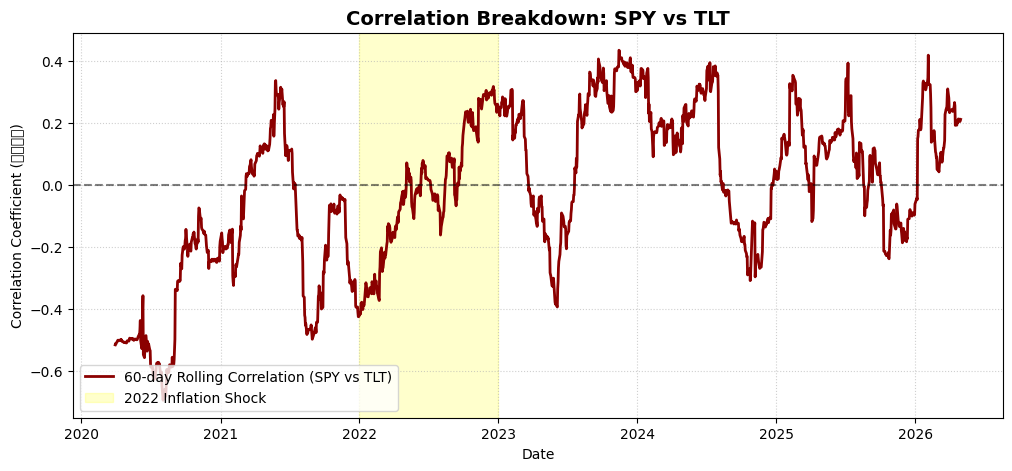

In [15]:
import matplotlib.pyplot as plt

# 1. 60일(약 3달) 이동 윈도우를 사용해 SPY와 TLT의 일별 수익률 상관관계 계산
# (윈도우가 하루씩 뒤로 이동하며 주식-채권의 관계가 어떻게 변하는지 실시간 추적합니다)
rolling_correlation = returns['SPY'].rolling(window=60).corr(returns['TLT'])

# 2. 상관관계 변화 추이 시각화
plt.figure(figsize=(12, 5))
plt.plot(rolling_correlation, color='darkred', linewidth=2, label='60-day Rolling Correlation (SPY vs TLT)')

# 3. 리스크 관리 관점의 가이드라인(기준선 및 위기 구간) 추가
plt.axhline(0, color='black', linestyle='--', alpha=0.5) # 상관계수 0 기준선

# 2022년 인플레이션 쇼크 구간을 노란색 음영으로 강조
plt.axvspan('2022-01-01', '2022-12-31', color='yellow', alpha=0.2, label='2022 Inflation Shock')

plt.title('Correlation Breakdown: SPY vs TLT', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Correlation Coefficient (상관계수)')
plt.legend(loc='lower left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

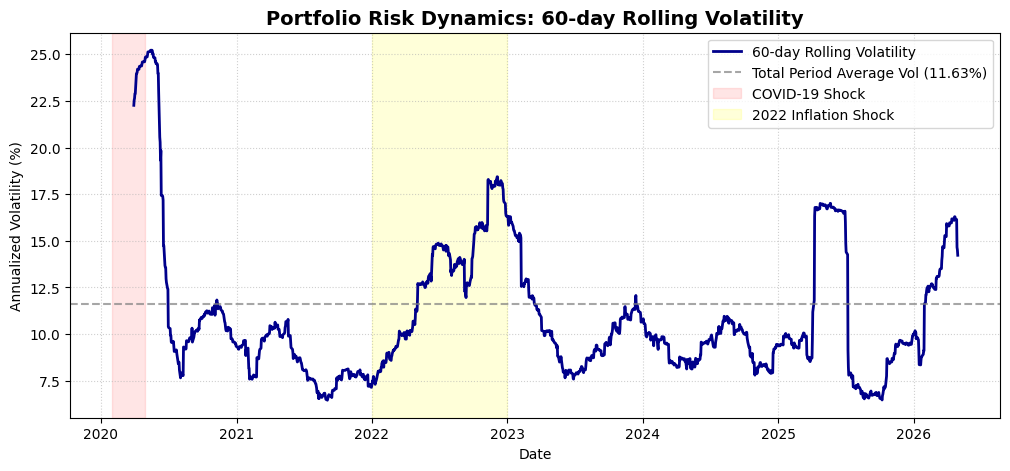

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 60일(약 3달) 이동 윈도우를 사용해 포트폴리오의 연율화 이동 변동성(Rolling Volatility) 계산
# (일별 표준편차에 루트 252를 곱해 연간 기준으로 환산합니다)
rolling_volatility = portfolio_return.rolling(window=60).std() * np.sqrt(252)

# 2. 이동 변동성 시각화
plt.figure(figsize=(12, 5))
plt.plot(rolling_volatility * 100, color='darkblue', linewidth=2, label='60-day Rolling Volatility')

# 3. 전체 기간 평균 변동성(11.63%)을 기준선으로 표시하여 비교
plt.axhline(11.63, color='gray', linestyle='--', alpha=0.7, label='Total Period Average Vol (11.63%)')

# 주요 위기 구간 음영 표시
plt.axvspan('2020-02-01', '2020-04-30', color='red', alpha=0.1, label='COVID-19 Shock')
plt.axvspan('2022-01-01', '2022-12-31', color='yellow', alpha=0.15, label='2022 Inflation Shock')

plt.title('Portfolio Risk Dynamics: 60-day Rolling Volatility', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility (%)')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [17]:
import numpy as np
import pandas as pd

# 1. 95% VaR 선(-1.12%)을 넘어선 최악의 하위 5% 폭락 날들의 수익률만 필터링
# (이미 이전 셀들에서 portfolio_return과 var_95_daily가 계산되어 있으므로 바로 연동됩니다)
tail_losses = portfolio_return[portfolio_return <= var_95_daily]

# 2. 그 지옥 같은 날들의 '평균 손실(Expected Shortfall)' 계산
expected_shortfall = tail_losses.mean()

# 3. 기존의 metrics_summary 표를 최종 진화형 고급 리스크 매트릭스 표로 업데이트
updated_metrics = pd.DataFrame({
    'Metric': [
        'Annualized Return (연수익률)',
        'Annualized Volatility (연변동성)',
        'Maximum Drawdown (MDD)',
        '95% Daily VaR (일별 VaR)',
        '95% Daily Expected Shortfall (기대손실, ES) 🌟'
    ],
    'Value': [
        f"{11.02}%",
        f"{11.63}%",
        f"{-22.63}%",
        f"{var_95_daily * 100:.2f}%",
        f"{expected_shortfall * 100:.2f}%"  # 오늘 새로 구한 ES 수치
    ]
})

print("=" * 55)
print("   [Project 01] Final Advanced Portfolio Metrics   ")
print("=" * 55)
print(updated_metrics.to_string(index=False))
print("=" * 55)

   [Project 01] Final Advanced Portfolio Metrics   
                                   Metric   Value
                 Annualized Return (연수익률)  11.02%
             Annualized Volatility (연변동성)  11.63%
                   Maximum Drawdown (MDD) -22.63%
                   95% Daily VaR (일별 VaR)  -1.12%
95% Daily Expected Shortfall (기대손실, ES) 🌟  -1.68%


In [18]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 확장된 자산군 데이터 다운로드 (PLTR, SLV 추가)
extended_tickers = ['SPY', 'PLTR', 'GLD', 'SLV', 'TLT']
# PLTR의 상장일(2020년 9월)을 고려하여 분석 시작일을 변경합니다.
ext_data = yf.download(extended_tickers, start='2020-10-01', end='2026-05-01')['Close']

# 2. 일별 수익률 계산
ext_returns = ext_data.pct_change().dropna()

# 3. 새로운 자산 비중 설정 (합계 = 1.0)
ext_weights = {'SPY': 0.30, 'PLTR': 0.10, 'GLD': 0.20, 'SLV': 0.10, 'TLT': 0.30}

# 4. 확장 포트폴리오의 일별 수익률 및 누적 수익률 합성
ext_portfolio_return = sum(ext_returns[ticker] * weight for ticker, weight in ext_weights.items())
ext_portfolio_cumulative = (1 + ext_portfolio_return).cumprod()

# 5. 확장 포트폴리오의 리스크 지표 계산
# 연수익률
ext_ann_return = (ext_portfolio_cumulative.iloc[-1]) ** (252 / len(ext_portfolio_return)) - 1
# 연변동성
ext_ann_vol = ext_portfolio_return.std() * np.sqrt(252)
# MDD
ext_rolling_max = ext_portfolio_cumulative.cummax()
ext_drawdown = (ext_portfolio_cumulative - ext_rolling_max) / ext_rolling_max
ext_mdd = ext_drawdown.min()
# 95% 일별 VaR 및 Expected Shortfall(ES)
ext_var_95 = np.percentile(ext_portfolio_return, 5)
ext_tail_losses = ext_portfolio_return[ext_portfolio_return <= ext_var_95]
ext_es = ext_tail_losses.mean()

# 6. 결과 스코어보드 출력
ext_metrics = pd.DataFrame({
    'Metric': ['Annualized Return', 'Annualized Volatility', 'Maximum Drawdown (MDD)', '95% Daily VaR', '95% Daily ES'],
    'Extended Portfolio (5 Assets)': [
        f"{ext_ann_return * 100:.2f}%", f"{ext_ann_vol * 100:.2f}%", f"{ext_mdd * 100:.2f}%", f"{ext_var_95 * 100:.2f}%", f"{ext_es * 100:.2f}%"
    ]
})

print("=" * 60)
print("     [Project 01 Revise] Extended Portfolio Risk Summary     ")
print("=" * 60)
print(ext_metrics.to_string(index=False))
print("=" * 60)

/tmp/ipykernel_1314/1697049473.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ext_data = yf.download(extended_tickers, start='2020-10-01', end='2026-05-01')['Close']
[*********************100%***********************]  5 of 5 completed


     [Project 01 Revise] Extended Portfolio Risk Summary     
                Metric Extended Portfolio (5 Assets)
     Annualized Return                        16.12%
 Annualized Volatility                        14.63%
Maximum Drawdown (MDD)                       -29.03%
         95% Daily VaR                        -1.42%
          95% Daily ES                        -2.02%
